In [1]:
from dotenv import load_dotenv, find_dotenv
import os
load_dotenv(find_dotenv(),override=True)
from IPython.display import Image, display
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [2]:
from langchain_core.output_parsers import JsonOutputParser
from langchain.output_parsers import PydanticOutputParser
from custom_types import SectionWebSearchResult, ReportGeneratorWorkflowState
from langchain_openai import ChatOpenAI
from topic_analyser import TopicAnalyzer
from web_researcher import WebResearcher
from section_writter import SectionWriter
from report_compiler import ReportCompiler
from custom_types import SectionOutLine
from typing import Dict, List,Optional

In [3]:
# Convenience function for LangGraph node
def topic_analyzer_node(state: ReportGeneratorWorkflowState) -> ReportGeneratorWorkflowState:
    """
    LangGraph node function for topic analysis.
    
    Args:
        state: Current workflow state
        
    Returns:
        Updated workflow state
    """
    
    analyzer = TopicAnalyzer()
    state.sections_ouline = analyzer.analyze_topic(state.topic)
    
    return state
        

In [4]:
async def researcher_node(state: ReportGeneratorWorkflowState) -> ReportGeneratorWorkflowState:
    """
    LangGraph node function for web research.
    
    Args:
        state: Current workflow state
        
    Returns:
        Updated workflow state
    """
 
    researcher = WebResearcher()
    sectionWebSearchResults = await researcher.research_sections(state.sections_ouline)
    print(f"*****Research completed for {len(sectionWebSearchResults)} sections.")
    state.sectionWebSearchResults = sectionWebSearchResults
  
   
    return state

In [5]:
from custom_utils import CustomUtils



In [6]:
async def section_writer_node(state: ReportGeneratorWorkflowState) -> ReportGeneratorWorkflowState:
    """
    LangGraph node function for section writer.
    
    Args:
        state: Current workflow state
        
    Returns:
        Updated workflow state
    """
    section_writter_dict = CustomUtils.merge_sections_by_title(outlines=state.sections_ouline,
                                                               search_results=state.sectionWebSearchResults)
  
    
    section_writer = SectionWriter()
  
    sections = await section_writer.write_all_sections(section_writter_dict)
    print(f"****Section writing completed for {len(sections)} sections.")
    state.sections = sections
   
    return state

In [7]:
def report_compiler_node(state: ReportGeneratorWorkflowState) -> ReportGeneratorWorkflowState:
    """
    LangGraph node function for report compilation.
    
    Args:
        state: Current workflow state
        
    Returns:
        Updated workflow state
    """
   
    
    # Assuming a method to compile sections into a final report
    report_compiler = ReportCompiler()
    final_report = report_compiler.compile_report(topic=state.topic , sections=state.sections)
    state.final_report = final_report
    report_path = report_compiler.save_report(report_content=final_report, topic=state.topic)
    state.final_report_path = report_path
    print(f"****Final report compiled at: {state.final_report_path}")
   
    return state

In [8]:
from langgraph.graph import StateGraph, END, START 
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

def build_workflow():
        """
        Builds the LangGraph StateGraph defining the report generation workflow.
        """
        workflow = StateGraph(ReportGeneratorWorkflowState)

        # 1. Add Nodes for each agent
        workflow.add_node("analyze_topic", topic_analyzer_node)
        workflow.add_node("research_web", researcher_node)
        workflow.add_node("write_sections", section_writer_node)
        workflow.add_node("compile_report", report_compiler_node)

        # 2. Define the Entry Point
        workflow.set_entry_point("analyze_topic")

        # 3. Define Edges (flow between nodes)
        workflow.add_edge("analyze_topic", "research_web")
         
        workflow.add_edge("research_web", "write_sections")
        workflow.add_edge("write_sections", END)
        workflow.add_edge("write_sections", "compile_report")
        workflow.add_edge("compile_report", END) # The report compilation is the end of the main flow

        # Compile the graph
        memory=MemorySaver()
        graph = workflow.compile(checkpointer=memory)
        display(Image(graph.get_graph().draw_mermaid_png()))
        return graph

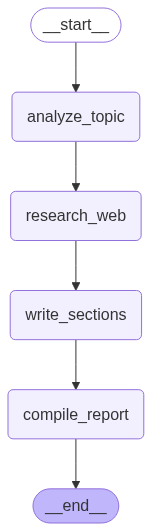

c:\VSCodeWorkSpace\.venv\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'title': 'Introduction t...storical developments.'}, input_type=dict])
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'title': 'Personalized L...ning styles and paces.'}, input_type=dict])
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'title': 'AI-Driven Educ...ng management systems.'}, input_type=dict])
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'title': 'Challenges and...he potential for bias.'}, input_type=dict])
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'ti

  Researching for section: 'Introduction to AI in Education' with query: 'Introduction to AI in Education: An overview of artificial intelligence and its integration into the educational landscape, including definitions and historical developments.'
  Researching for section: 'Personalized Learning Experiences' with query: 'Personalized Learning Experiences: Exploration of how AI enables personalized learning pathways for students, adapting to individual learning styles and paces.'
  Researching for section: 'AI-Driven Educational Tools and Technologies' with query: 'AI-Driven Educational Tools and Technologies: Analysis of various AI tools and technologies currently used in education, such as intelligent tutoring systems, chatbots, and learning management systems.'
  Researching for section: 'Challenges and Ethical Considerations' with query: 'Challenges and Ethical Considerations: Discussion of the challenges and ethical implications of using AI in education, including data privacy, 

In [ ]:
thread = {'configurable': {'thread_id': '1'}}
graph = build_workflow()

prompt = {
    'topic': "The impact of AI on modern education",
  
}

result = await graph.ainvoke(prompt, thread)
print(f"Workflow completed with state: {result}")
# print(f"Final report path: {result.final_report_path}")  
# async for chunk in graph.astream(prompt, thread):
#     print(chunk)
             
             